In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [3]:
import pandas as pd
from glob import glob
from tqdm import tqdm
from skimage import io

In [4]:
from skimage.transform import rotate, resize
from skimage.exposure import equalize_adapthist

In [5]:
path_images = './00.data/cropped_old/'
path_labels = './RotatedImageFiles.txt'

In [6]:
data_files = glob(path_images+'*')
data_files_zero = [path for path in data_files if '_0.jpg' in path]
data_labels = pd.read_csv(path_labels)

In [7]:
data_labels.index = data_labels.Filename.values

In [8]:
data_zero = data_labels.loc[data_labels.Filename.str.contains('_0.jpg')].copy()

In [9]:
print(data_labels.shape)

data_labels.head(2)

(1092, 2)


,Filename,Doppler_Angle
09-41-06_1_-30.jpg,09-41-06_1_-30.jpg,58.3653
09-41-06_1_-25.jpg,09-41-06_1_-25.jpg,63.3653


In [10]:
print(data_zero.shape)

data_zero.head(2)

(84, 2)


,Filename,Doppler_Angle
09-41-06_1_0.jpg,09-41-06_1_0.jpg,88.3653
09-41-06_2_0.jpg,09-41-06_2_0.jpg,88.2701


In [11]:
def get_image(img_path):
    
    img = io.imread(img_path)
    
    return(img)


def get_label(img_path,out=data_labels):
    
    img_id = img_path.split('/')[-1]
    row = out.loc[img_id]
    angle = row['Doppler_Angle']
    
    return(angle)

In [12]:
data_x = [get_image(path) for path in data_files]
data_y = [get_label(path) for path in data_files]

In [13]:
data_x_zero = [get_image(path) for path in data_files_zero]
data_y_zero = [get_label(path) for path in data_files_zero]

(84.032200000000003, -10, 74.032200000000003)


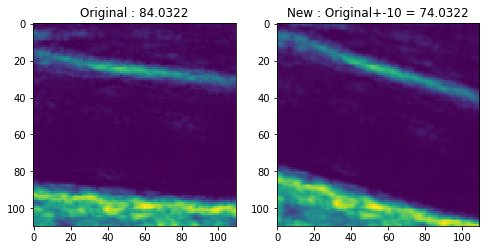

In [14]:
angle_set = np.arange(-30,35,5)
rotation_angle = np.random.choice(a = angle_set)
image_index = np.random.choice(np.arange(0,len(data_x_zero)))

img_x = data_x_zero[image_index]
img_y = data_y_zero[image_index]
new_angle = img_y+rotation_angle


img_x = resize(img_x,(110,110),mode='reflect')
img_rot = rotate(img_x,angle=rotation_angle,mode='reflect')


print(img_y,rotation_angle,new_angle)

plt.figure(figsize=(8,6))

plt.subplot(121)
plt.imshow(img_x)
plt.title('Original : '+str(img_y));

plt.subplot(122)
plt.imshow(img_rot)
plt.title('New : Original'+'+'+str(rotation_angle)+' = '+str(new_angle));

86.458


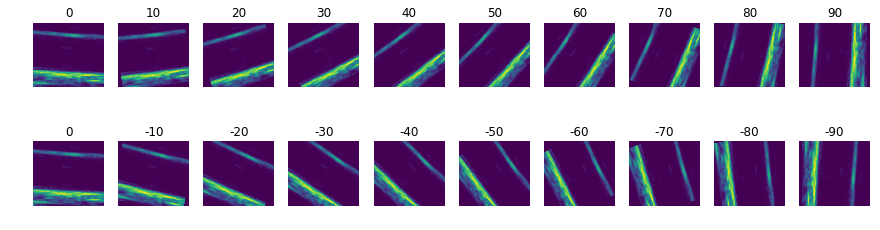

In [15]:
img_path = data_files_zero[0]
img_id = img_path.split('/')[-1]
img_zero = plt.imread(img_path)

img_cols = 10
rotation_step = 10

i = 1

print(data_labels.loc[img_id]['Doppler_Angle'])
plt.figure(figsize=(15,4))
for ix in range(img_cols):
    angle_pos = ix*rotation_step
    angle_neg = -1*ix*rotation_step
    
    img_rot01 = rotate(img_zero,angle=angle_pos)
    img_rot02 = rotate(img_zero,angle=angle_neg)
    
    plt.subplot(2,img_cols,i)
    plt.imshow(img_rot01)
    plt.title(angle_pos)
    plt.axis('off')
    
    plt.subplot(2,img_cols,i+img_cols)
    plt.imshow(img_rot02)
    plt.title(angle_neg)
    plt.axis('off');
    
    i+=1

In [16]:
def image_generator(input_data,
                    output_data,
                    batch_size=25,
                    img_channels=3,
                    rotation_range=60,
                    negative=False,
                    input_size=(100, 100),
                    equalize_hist=True):

    img_rows, img_cols = input_size

    while True:
        
        batch_files = np.random.choice(input_data, batch_size, replace=True)
        
        if negative:
            start_range = -1 * rotation_range
        else:
            start_range = 0
            
        angle_set = np.arange(start_range,rotation_range,5)
        
        batch_images = []
        batch_labels = []

        for current_file in batch_files:

            rotation_angle = np.random.choice(a = angle_set)
            current_image = get_image(current_file)
            
            current_label = get_label(current_file,output_data)
            new_angle = current_label+rotation_angle
            
            
            if equalize_hist:
                current_image = equalize_adapthist(current_image)
                
            if new_angle>180:
                new_angle-=180

            current_image = resize(current_image,(img_rows,img_cols),mode='reflect')
            current_image = rotate(current_image,angle=rotation_angle,mode='reflect')
            
            batch_images.append(current_image)
            batch_labels.append(new_angle)

        batch_images = np.array(batch_images)
        batch_labels = np.array(batch_labels)
        
        batch_images = np.expand_dims(batch_images,-1)
        batch_labels = np.expand_dims(np.expand_dims(np.expand_dims(batch_labels,1),1),1)
        
        batch_x, batch_y = batch_images, batch_labels

        yield (batch_x, batch_y)

In [17]:
from keras import backend as K
from keras.layers import Input, BatchNormalization, Conv2D, Dense, Activation, Dropout
from keras.models import Model

Using TensorFlow backend.


In [18]:
img_size = (100,100,1)
dropout_rate = 0.25

In [19]:
K.clear_session()

main_input = Input(shape=img_size)

x = BatchNormalization()(main_input)
x = Conv2D(filters=16, kernel_size=(8,8))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=32, kernel_size=(6,6),strides=(5,5))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=64, kernel_size=(4,4),strides=(3,3))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=128, kernel_size=(2,2),strides=(2,2))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = BatchNormalization()(x)
x = Conv2D(filters=256, kernel_size=(2,2),strides=(1,1))(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)


#x = BatchNormalization()(x)
#x = Conv2D(filters=512, kernel_size=(2,2),strides=(1,1))(x)
#x = Activation('relu')(x)
#x = Dropout(dropout_rate)(x)

#x = BatchNormalization()(x)
#x = Dense(units=512)(x)
#x = Activation('relu')(x)
#x = Dropout(dropout_rate)(x)

x = Dense(units=1)(x)
main_output = Activation('relu')(x)

model = Model(inputs=[main_input], outputs=[main_output])

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 100, 100, 1)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 100, 100, 1)       4         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 93, 93, 16)        1040      
_________________________________________________________________
activation_1 (Activation)    (None, 93, 93, 16)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 93, 93, 16)        0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 93, 93, 16)        64        
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 18, 18, 32)        18464     
__________

In [20]:
train_generator = image_generator(data_files_zero[:-10],data_zero,rotation_range=60, negative=True)
test_generator = image_generator(data_files_zero[-10:],data_zero,rotation_range=60, negative=True)

In [21]:
from keras.callbacks import ModelCheckpoint,EarlyStopping

MC = ModelCheckpoint(filepath='./model/model_02.h5')
ES = EarlyStopping(patience=10)

In [22]:
model.compile(optimizer='adam',loss='mse')
model.fit_generator(generator=train_generator,
                    validation_data = test_generator,
                    callbacks=[MC,ES],
                    steps_per_epoch=100,
                    validation_steps=10,
                    epochs=100,
                    verbose=2)

Epoch 1/100
 - 84s - loss: 2043.5155 - val_loss: 3457.5343
Epoch 2/100
 - 77s - loss: 159.8715 - val_loss: 1209.7400
Epoch 3/100
 - 76s - loss: 95.3751 - val_loss: 478.1570
Epoch 4/100
 - 77s - loss: 71.1325 - val_loss: 149.8240
Epoch 5/100
 - 77s - loss: 63.1697 - val_loss: 222.8174
Epoch 6/100
 - 77s - loss: 57.8381 - val_loss: 212.1403
Epoch 7/100
 - 77s - loss: 52.0694 - val_loss: 169.3686
Epoch 8/100
 - 77s - loss: 46.6877 - val_loss: 184.0112
Epoch 9/100
 - 77s - loss: 48.2239 - val_loss: 181.8361
Epoch 10/100
 - 77s - loss: 47.4213 - val_loss: 244.9783
Epoch 11/100
 - 77s - loss: 43.2055 - val_loss: 169.6804
Epoch 12/100
 - 77s - loss: 45.1020 - val_loss: 147.9501
Epoch 13/100
 - 77s - loss: 41.7673 - val_loss: 99.5472
Epoch 14/100
 - 77s - loss: 41.1739 - val_loss: 225.9606
Epoch 15/100
 - 77s - loss: 41.5914 - val_loss: 108.4944
Epoch 16/100
 - 78s - loss: 39.9630 - val_loss: 98.3961
Epoch 17/100
 - 77s - loss: 36.1059 - val_loss: 109.5958
Epoch 18/100
 - 77s - loss: 38.2492 -

In [23]:
from keras.models import load_model

model = load_model('./model/model_02.h5')

In [24]:
from tqdm import tqdm

In [25]:
def two_scales(ax1, x, data1, data2, c1, c2):
    """

    Parameters
    ----------
    ax : axis
        Axis to put two scales on

    x : array-like
        x-axis values for both datasets

    data1: array-like
        Data for left hand scale

    data2 : array-like
        Data for right hand scale

    c1 : color
        Color for line 1

    c2 : color
        Color for line 2

    Returns
    -------
    ax : axis
        Original axis
    ax2 : axis
        New twin axis
    """
    ax2 = ax1.twinx()

    ax1.scatter(x, data1, color=c1, alpha=0.5, s=10)
    ax1.set_xlabel('$Y$ ( Actual )')
    ax1.set_ylabel('$\hat{Y}$ ( Predicted)',rotation=0)

    ax2.scatter(x, data2, color=c2, alpha=0.5, s=5)
    ax2.set_ylabel('$\Delta$ ( Error )',rotation=0)
    return ax1, ax2

In [26]:
images_actual = []
y_actual = []
y_predicted = []

for i in tqdm(range(100)):
    
    x,y_real = test_generator.next()
    y_predict = model.predict_on_batch(x)
    
    images_actual+=[x]
    y_actual += [y_real]
    y_predicted += [y_predict]

images_actual = np.concatenate(images_actual)
y_real = np.concatenate(y_actual)
y_predicted = np.concatenate(y_predicted)

100%|██████████| 100/100 [01:10<00:00,  1.42it/s]


In [27]:
images_actual = np.squeeze(images_actual,axis=-1)
y_real = np.squeeze(np.squeeze(y_real,axis=-1))
y_predicted = np.squeeze(np.squeeze(y_predicted,axis=-1))

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

(0.85824504373371102, 13.204801363387961)


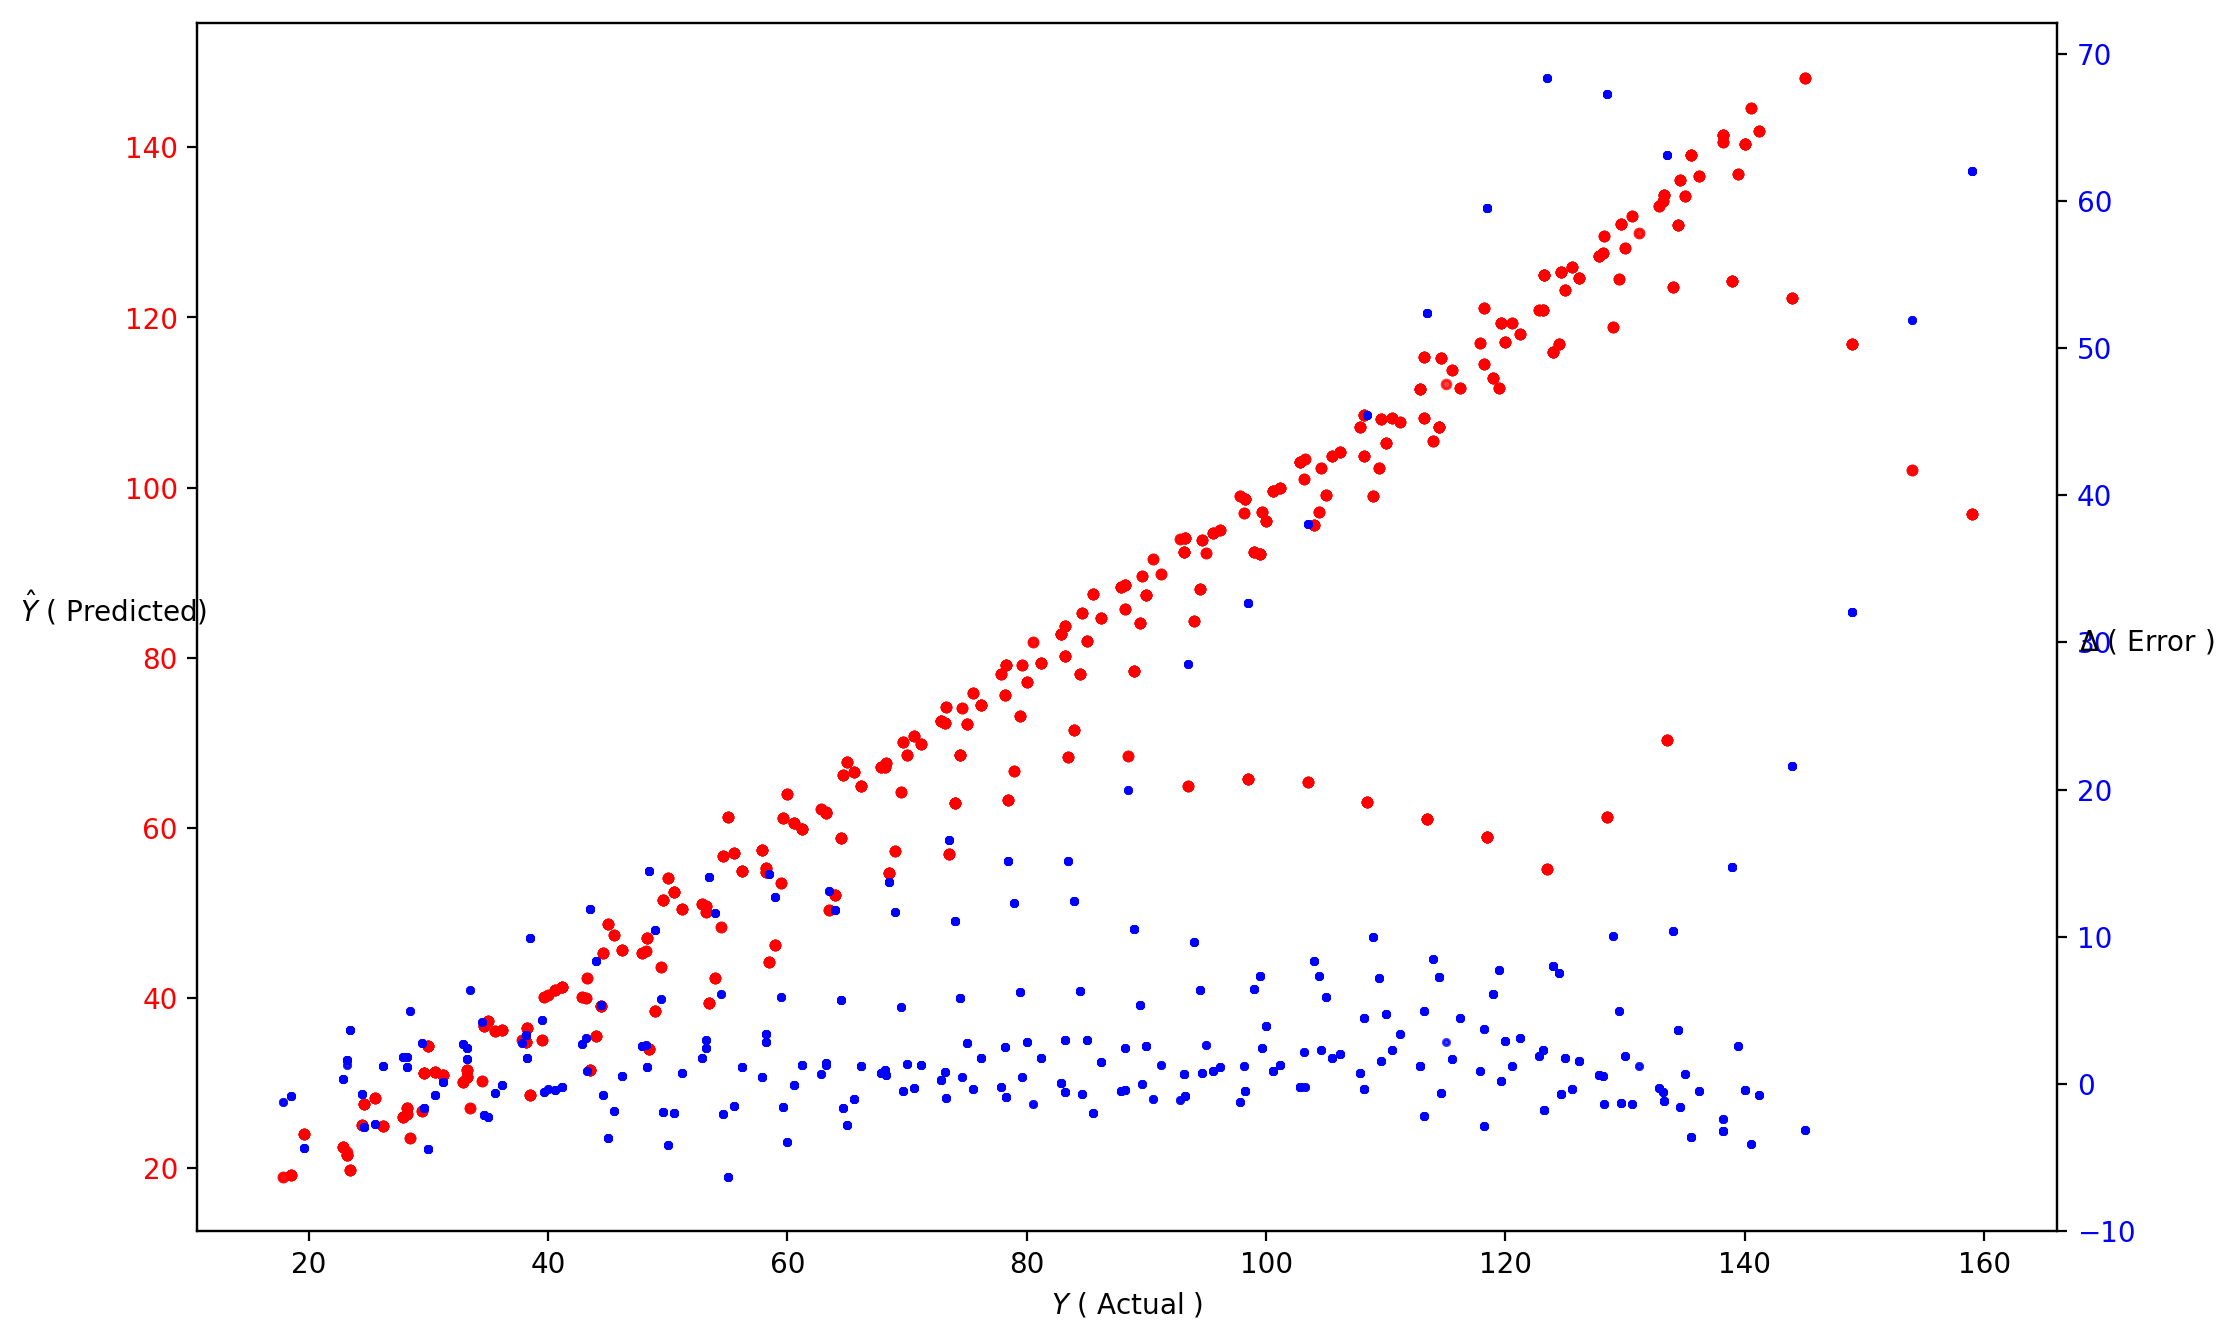

In [29]:
x_c = y_real
y_1 = y_predicted
y_2 = y_real-y_predicted

fig, ax = plt.subplots(figsize=(12,8), dpi=200)
ax1, ax2 = two_scales(ax1 = ax, 
                      x = x_c, 
                      data1 = y_1, 
                      data2 = y_2, 
                      c1 = 'r', 
                      c2 = 'b')


# Change color of each axis
def color_y_axis(ax, color):
    """Color your axes."""
    for t in ax.get_yticklabels():
        t.set_color(color)
    return None

print(
    r2_score(y_real, y_predicted),
    np.sqrt(mean_squared_error(y_real, y_predicted))
)

color_y_axis(ax1, 'r')
color_y_axis(ax2, 'b')

In [30]:
np.sqrt(mean_squared_error(y_real[np.absolute(y_2)<30], 
                           y_predicted[np.absolute(y_2)<30]))

5.6189719596372658

#### Images with largest errors

In [31]:
image_set = images_actual[np.absolute(y_2)>30]
(
    x_c[np.absolute(y_2)>30],
    y_1[np.absolute(y_2)>30]
)

(array([ 113.4682,  103.4682,   98.4682,  158.9619,  118.4682,  123.4682,
         153.9619,  113.4682,  123.4682,  118.4682,  148.9619,  133.4682,
         128.4682,  108.4682,  148.9619,  123.4682,   98.4682,  128.4682,
         128.4682,  153.9619,  113.4682,  158.9619,  113.4682,  123.4682,
         128.4682,  148.9619,  148.9619,  148.9619,  103.4682,  148.9619,
         103.4682,  148.9619,  118.4682,  113.4682,  113.4682,   98.4682,
         113.4682,  118.4682,  118.4682,   98.4682,  113.4682,  123.4682,
         158.9619,  108.4682,  148.9619,   98.4682,  158.9619,  108.4682,
         113.4682,  103.4682,  103.4682,   98.4682,  103.4682,  133.4682,
         108.4682,  148.9619,  158.9619,  133.4682,  148.9619,  158.9619,
         113.4682,  128.4682,  108.4682,  113.4682,  133.4682,  118.4682,
         128.4682,  118.4682,   98.4682,  133.4682,  128.4682,  123.4682,
         113.4682,  108.4682,   98.4682,   98.4682,  158.9619,  153.9619,
          98.4682,  133.4682,  103.468

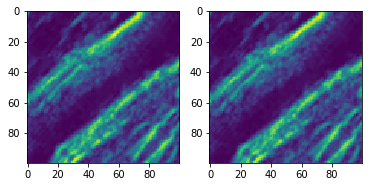

In [32]:
plt.subplot(121)
plt.imshow(image_set[-3]);

plt.subplot(122)
plt.imshow(image_set[-2]);